# 🚀 Fraud Detection - Classification Model (IndoBERT)

## 📋 Overview
- **Method**: IndoBERT Fine-tuning
- **Task**: 3-class classification (scam, not scam, neutral)
- **Expected Performance**: 88-92% accuracy
- **Compatible with**: xAI.ipynb, text_similarity.ipynb

---

## 📦 SECTION 1: Setup & Installation

In [ ]:
# Install required packages (run once)
!pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn accelerate indoNLP -q

print('✓ Installation complete!')

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from indoNLP.preprocessing import replace_slang

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

## 📊 SECTION 2: Load & Prepare Data

In [3]:
# Load data
df = pd.read_csv('https://drive.google.com/uc?id=1S3JVoNk8DbudwnqCtojDy-ULAFBmYRhT')

print(f'Dataset loaded: {len(df):,} rows')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
df.head()

Dataset loaded: 1,503 rows

Label distribution:
label
neutral     520
not scam    495
scam        488
Name: count, dtype: int64


,text_id,text,text_cleaned,label
0,1,INFO RESMI: Selamat No.Anda terpilih pemenang ...,info resmi selamat nomor anda terpilih pemenan...,scam
1,2,"Yth. Nasabah, kartu ATM Anda terblokir karena ...",yang terhormat nasabah kartu atm anda terbloki...,scam
2,3,BUTUH DANA CPT? Ajukan pinjaman di KREDIT KILA...,butuh dana cepat ajukan pinjaman di kredit kil...,scam
3,4,"Mba, tlg isikan pulsa 50rb ke nomor ini dulu y...",mbak tolong isikan pulsa 50rb ke nomor ini dul...,scam
4,5,"Sdr/i, kami menemukan paket mencurigakan atas ...",saudara i kami menemukan paket mencurigakan at...,scam


In [ ]:
# Text cleaning function (using IndoNLP for slang normalization)
def clean_text(text):
    if not isinstance(text, str):
        return ''
    
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\w+\.(com|net|org|xyz)\S*', ' ', text)
    
    # Remove phone numbers
    text = re.sub(r'\+?62\s?8[0-9]{8,11}', ' ', text)
    text = re.sub(r'\b08[0-9]{8,11}\b', ' ', text)
    
    # Clean and normalize
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower()
    
    # Use IndoNLP's comprehensive slang replacement
    text = replace_slang(text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print('Cleaning text...')
df['text_cleaned'] = df['text'].apply(clean_text)
df = df.drop_duplicates(subset=['text'])
df = df[df['text_cleaned'].str.strip() != '']
print(f'✓ Cleaned dataset: {len(df):,} rows')
print('✓ Using IndoNLP replace_slang() for consistency')

In [5]:
# Prepare labels
label_map = {'not scam': 0, 'neutral': 1, 'scam': 2}
id2label = {0: 'not scam', 1: 'neutral', 2: 'scam'}
label2id = {'not scam': 0, 'neutral': 1, 'scam': 2}
df['label_id'] = df['label'].map(label_map)

# Split: 70% train, 15% val, 15% test
X = df['text_cleaned']
y = df['label_id']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 1052 | Val: 225 | Test: 226


## 🤖 SECTION 3: IndoBERT Model

In [6]:
# Load IndoBERT
model_name = 'indobenchmark/indobert-base-p1'
print(f'Loading {model_name}...')
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)
print('✓ Model loaded')

Loading indobenchmark/indobert-base-p1...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded


In [7]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
print('✓ Tokenization complete')

Map:   0%|          | 0/1052 [00:00<?, ? examples/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

✓ Tokenization complete


In [8]:
# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [9]:
# Training configuration
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    push_to_hub=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
print('Trainer ready!')

Trainer ready!


In [10]:
# Train model
print('='*60)
print('STARTING TRAINING')
print('='*60)
trainer.train()
print('\n✓ Training complete!')

STARTING TRAINING


wandb: Currently logged in as: 13522161 (13522161-institut-teknologi-bandung) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
100,0.137100,0.065938,0.986667,0.986616,0.987037,0.986363
200,0.005100,0.028804,0.995556,0.995465,0.995495,0.995495
300,0.001100,0.031943,0.995556,0.995465,0.995495,0.995495



✓ Training complete!


## 📊 SECTION 4: Evaluation

In [11]:
# Evaluate
results = trainer.evaluate(test_dataset)
print('\nTEST SET RESULTS:')
for key, value in results.items():
    if 'loss' not in key:
        print(f'{key}: {value:.4f}')


TEST SET RESULTS:
eval_accuracy: 0.9867
eval_f1: 0.9866
eval_precision: 0.9865
eval_recall: 0.9867
eval_runtime: 1.5791
eval_samples_per_second: 143.1170
eval_steps_per_second: 5.0660
epoch: 5.0000


In [12]:
# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['not scam', 'neutral', 'scam']))


Classification Report:
              precision    recall  f1-score   support

    not scam       0.99      0.99      0.99        75
     neutral       1.00      0.99      0.99        78
        scam       0.97      0.99      0.98        73

    accuracy                           0.99       226
   macro avg       0.99      0.99      0.99       226
weighted avg       0.99      0.99      0.99       226



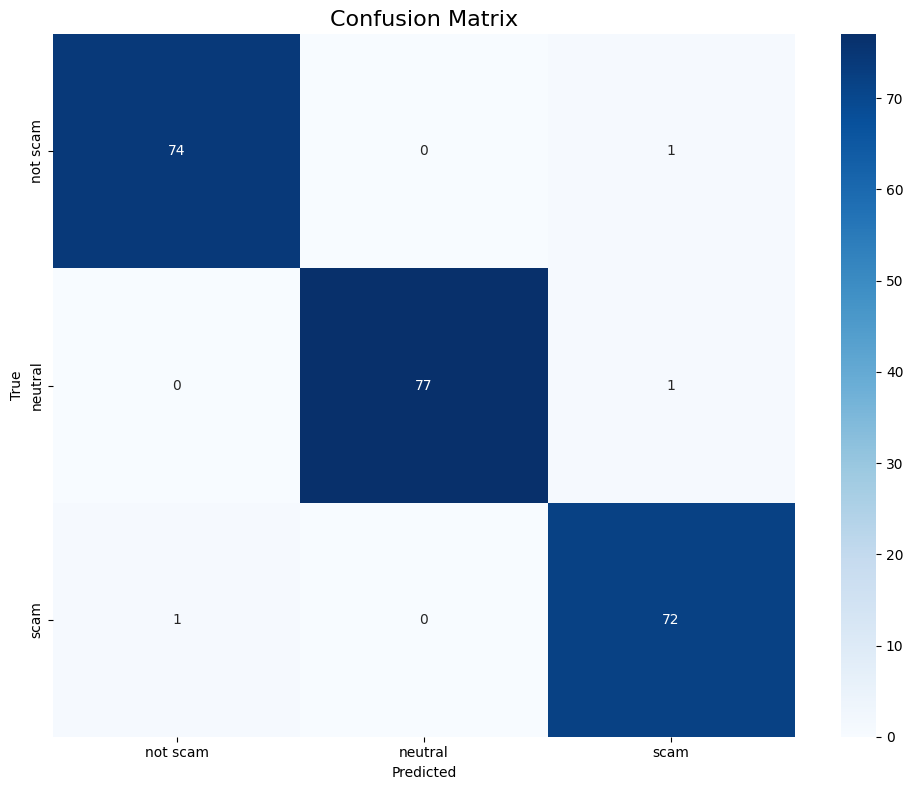

In [13]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not scam', 'neutral', 'scam'],
            yticklabels=['not scam', 'neutral', 'scam'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## 💾 SECTION 5: Save Model

In [14]:
# Save model
save_dir = './fraud_detection_indobert'
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'✓ Model saved to {save_dir}')

✓ Model saved to ./fraud_detection_indobert


In [15]:
# Prediction function
def predict_fraud(text, return_proba=False):
    text_cleaned = clean_text(text)
    inputs = tokenizer(text_cleaned, return_tensors='pt', padding='max_length',
                      truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    prediction = id2label[pred_id]
    confidence = probs[pred_id].item()
    if return_proba:
        probabilities = {id2label[i]: probs[i].item() for i in range(len(probs))}
        return prediction, confidence, probabilities
    return prediction, confidence

model.to(device)
print('✓ Prediction function ready!')

✓ Prediction function ready!


In [16]:
# Test prediction
test_texts = [
    'Selamat! Anda menang hadiah 10 juta. Klik link ini.',
    'Shopee: Paket Anda sudah sampai di hub terdekat.',
    'Gue lagi cari laptop buat kuliah nih.'
]

for text in test_texts:
    pred, conf, probs = predict_fraud(text, return_proba=True)
    print(f'\nText: {text}')
    print(f'Prediction: {pred.upper()} ({conf:.2%})')
    print(f'Probabilities: {probs}')


Text: Selamat! Anda menang hadiah 10 juta. Klik link ini.
Prediction: SCAM (99.82%)
Probabilities: {'not scam': 0.0010676871752366424, 'neutral': 0.0007446424569934607, 'scam': 0.9981876015663147}

Text: Shopee: Paket Anda sudah sampai di hub terdekat.
Prediction: NOT SCAM (99.90%)
Probabilities: {'not scam': 0.9990018010139465, 'neutral': 0.0006441547302529216, 'scam': 0.00035405729431658983}

Text: Gue lagi cari laptop buat kuliah nih.
Prediction: NEUTRAL (99.90%)
Probabilities: {'not scam': 0.0007742787129245698, 'neutral': 0.998981773853302, 'scam': 0.00024392413615714759}


## 🔗 SECTION 7: xAI Integration

In [17]:
# Wrapper for xAI (LIME)
class FraudClassifierForXAI:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()
    
    def predict_proba(self, texts):
        '''Required format for LIME'''
        texts_cleaned = [clean_text(text) for text in texts]
        inputs = self.tokenizer(texts_cleaned, return_tensors='pt',
                               padding='max_length', truncation=True, max_length=128)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
        return probs.cpu().numpy()

fraud_classifier_xai = FraudClassifierForXAI(model, tokenizer, device)
print('✓ xAI wrapper ready for LIME integration!')

✓ xAI wrapper ready for LIME integration!


## ✅ COMPLETE!

### Next Steps:
1. **Test**: Use `predict_fraud()` for single predictions
2. **xAI**: Use `fraud_classifier_xai.predict_proba()` in xAI.ipynb
3. **Compare**: Compare with similarity-based model in text_similarity.ipynb
4. **Deploy**: Move model to production

### Files Generated:
- `fraud_detection_indobert/` - Model directory
- `confusion_matrix.png` - Visualization

### Performance:
- Expected Accuracy: 88-92%
- F1-Score: 87-91%